In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import tensorflow as tf
import cv2
from tensorflow import keras
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from tensorflow.keras.layers import Dense,Dropout, Activation, Flatten, Conv2D, MaxPooling2D
from tensorflow.keras.models import Sequential
from tensorflow.keras.regularizers import l2
import os
from PIL import Image
import re

In [10]:
root = '/kaggle/input/anyas-gojo-revival-aerospace-enigma'
path_to_test = '/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma/test'
path_to_train = '/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma/train'
path_to_res = '/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma/sample_submission.csv'

In [11]:
train_val_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,      # Degree range for random rotations
    width_shift_range=0.2,  # Fraction of total width for random horizontal shift
    height_shift_range=0.2, # Fraction of total height for random vertical shift
    shear_range=0.2,        # Shear intensity (shear angle in radians)
    zoom_range=0.2,         # Range for random zoom
    horizontal_flip=True,   # Randomly flip inputs horizontally
    vertical_flip=True,     # Randomly flip inputs vertically
    fill_mode='nearest',     # Strategy for filling in newly created pixels (e.g., 'nearest')
    validation_split=0.15,
)
test_datagen = ImageDataGenerator(rescale=1./255)
batch_size = 32
image_size = (299, 299)

# Training Generator
train_generator = train_val_datagen.flow_from_directory(
    path_to_train,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='training',
    shuffle=True
)

# Validation Generator
val_generator = train_val_datagen.flow_from_directory(
    path_to_train,
    target_size=image_size,
    batch_size=batch_size,
    class_mode='categorical',
    subset='validation',
    shuffle=False
)

Found 1993 images belonging to 5 classes.
Found 348 images belonging to 5 classes.


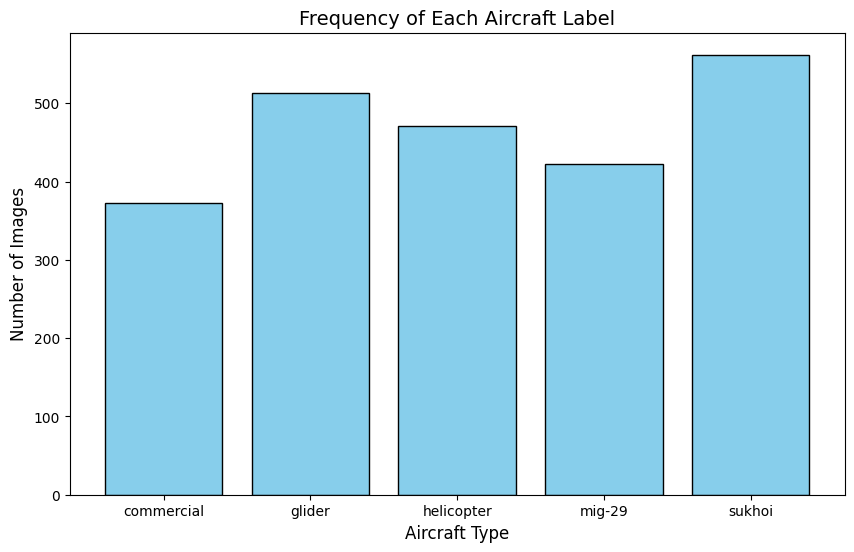

In [13]:
classes = ["commercial", "glider", "helicopter", "mig-29", "sukhoi"]
counts = []

for c in classes:
    class_path = os.path.join(path_to_train, c)
    if os.path.exists(class_path):
        counts.append(len(os.listdir(class_path)))
    else:
        counts.append(0)

plt.figure(figsize=(10, 6))
plt.bar(classes, counts, color='skyblue', edgecolor='black')
plt.xlabel('Aircraft Type', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.title('Frequency of Each Aircraft Label', fontsize=14)
plt.show()

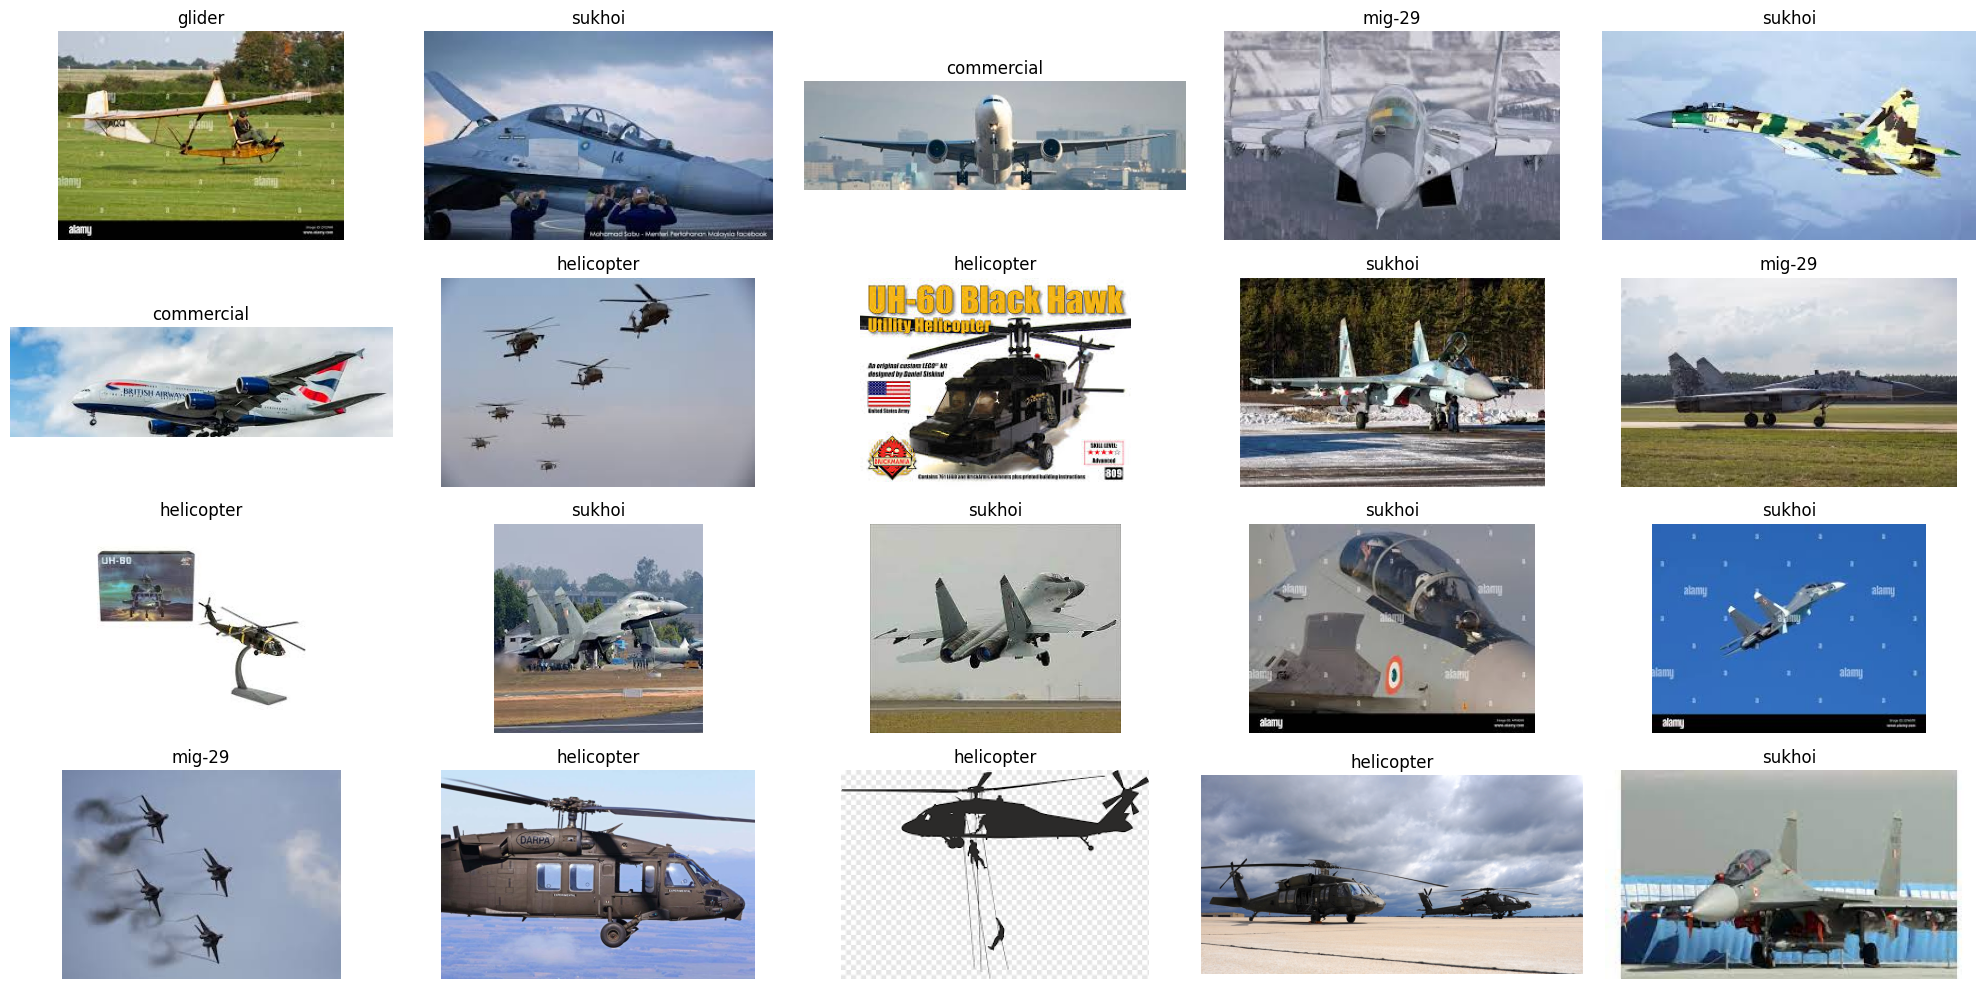

In [15]:
import random
import matplotlib.image as mpimg

def view_random_images():
    images = []
    labels = []
    root = '/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma' 
    
    class_list = list(train_generator.class_indices.keys())
    
    for i in range(20):
        random_class_name = random.choice(class_list)
        random_path = os.path.join(root, "train", random_class_name)
        
        all_images = os.listdir(random_path)
        random_image_name = random.choice(all_images)
        
        images.append(os.path.join(random_path, random_image_name))
        labels.append(random_class_name)

    plt.figure(figsize=(20, 10))
    for i in range(1, 21):
        plt.subplot(4, 5, i) 
        img = mpimg.imread(images[i-1])
        plt.imshow(img)
        plt.title(labels[i-1])
        plt.axis(False)
    plt.tight_layout()
    plt.show()

view_random_images()

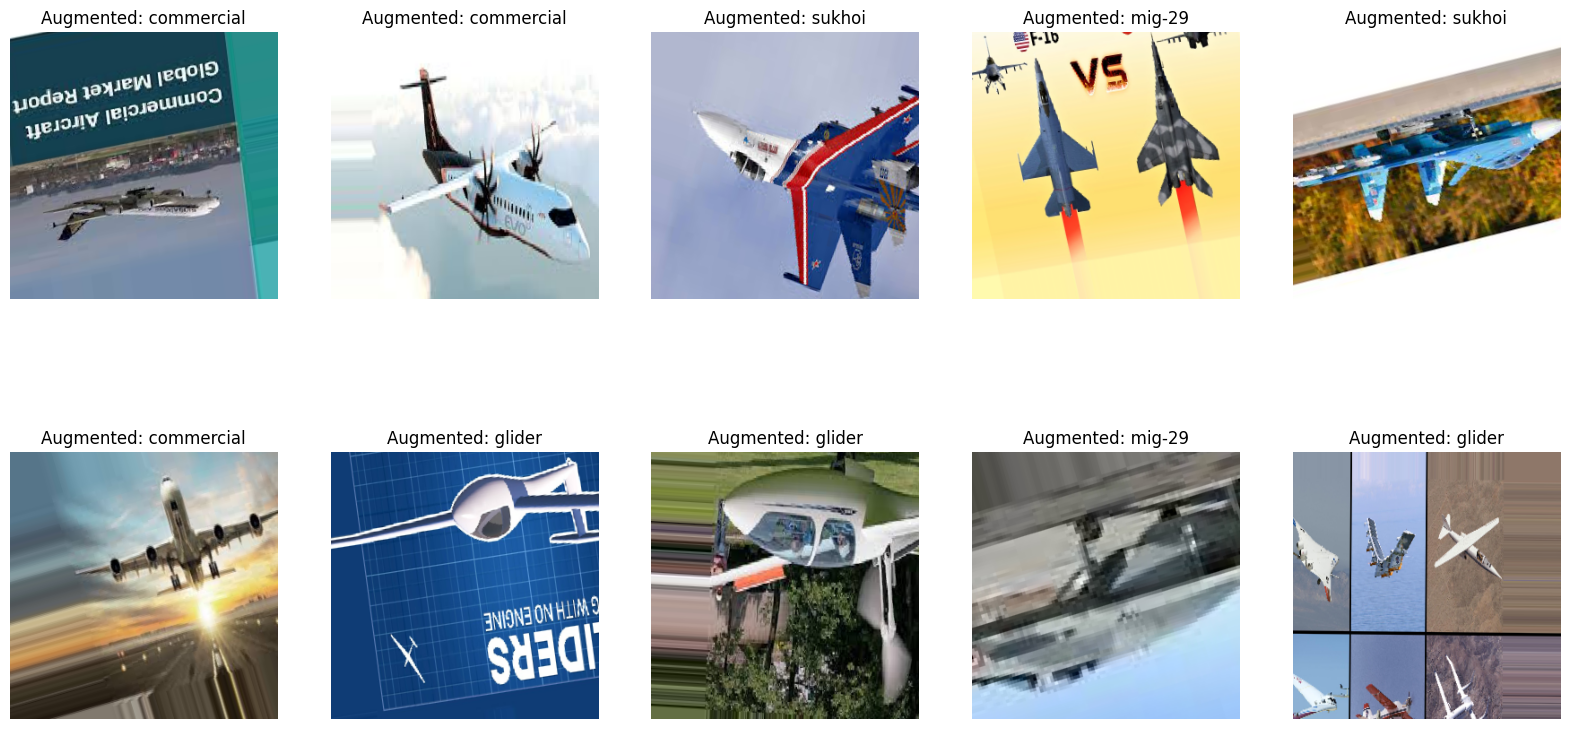

In [16]:
def view_augmented_images(generator):
    images, labels = next(generator)
    
    plt.figure(figsize=(20, 10))
    for i in range(10):
        plt.subplot(2, 5, i + 1)
        plt.imshow(images[i])
        class_idx = np.argmax(labels[i])
        class_name = list(generator.class_indices.keys())[class_idx]
        
        plt.title(f"Augmented: {class_name}")
        plt.axis(False)
    plt.show()

view_augmented_images(train_generator)

In [20]:
from tensorflow.keras.applications import Xception
from tensorflow.keras.layers import GlobalAveragePooling2D
base_model = Xception(input_shape=(299,299,3),weights='imagenet',include_top=False)
base_model.trainable = False #Free the base model
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(256,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(64,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(5,activation='softmax'))
callback1 = EarlyStopping(monitor='val_loss', patience=3, verbose=1, mode='auto', restore_best_weights=True)
callback2 = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=2, verbose=1, mode='auto', min_delta=1e-6)

epochs = 15
model.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss=tf.keras.losses.CategoricalCrossentropy(),
    metrics=["accuracy"],
)

In [21]:
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,402,797 (81.65 MB)

 Trainable params: 541,317 (2.06 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [39]:
history_xcep = model.fit(
    train_generator,
    epochs=epochs,
    callbacks=[callback1, callback2],
    validation_data=val_generator,
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 55s 869ms/step - accuracy: 0.8377 - loss: 0.4260 - val_accuracy: 0.8075 - val_loss: 0.4775 - learning_rate: 1.0000e-07
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 793ms/step - accuracy: 0.8494 - loss: 0.3931 - val_accuracy: 0.7845 - val_loss: 0.5009 - learning_rate: 1.0000e-07
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 680ms/step - accuracy: 0.8401 - loss: 0.4133
Epoch 3: ReduceLROnPlateau reducing learning rate to 1.0000000116860975e-08.
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 802ms/step - accuracy: 0.8400 - loss: 0.4135 - val_accuracy: 0.7845 - val_loss: 0.5166 - learning_rate: 1.0000e-07
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 812ms/step - accuracy: 0.8281 - loss: 0.4357 - val_accuracy: 0.8075 - val_loss: 0.4686 - learning_rate: 1.0000e-08
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 803ms/step - accuracy: 0.8232 - loss: 0.4239 - val_accuracy: 0.7787 - val_loss: 0.4915 - learning_rate: 1.0000e-08
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 689ms/step - accuracy:

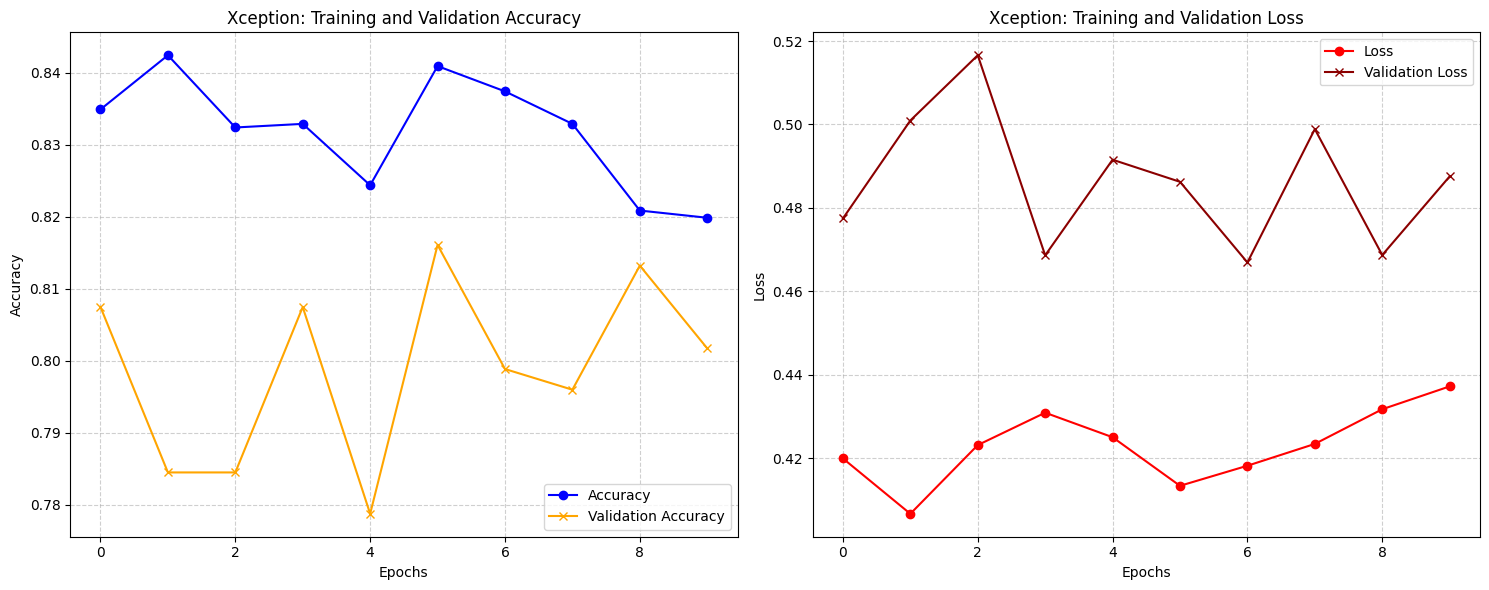

In [47]:
acc = history_xcep.history['accuracy']
val_acc = history_xcep.history['val_accuracy']
loss = history_xcep.history['loss']
val_loss = history_xcep.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('Xception: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('Xception: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [24]:
base_model.trainable = True

for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(
    optimizer=keras.optimizers.Adam(1e-5), 
    loss='categorical_crossentropy',
    metrics=["accuracy"]
)

history_fine = model.fit(
    train_generator,
    epochs=15,
    validation_data=val_generator,
    callbacks=[callback1, callback2]
)

Epoch 1/15


2026-03-03 08:18:48.555686: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:18:48.710025: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:18:49.854706: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:18:49.994123: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:18:50.606254: E external/local_xla/xla/stream_

27/63 ━━━━━━━━━━━━━━━━━━━━ 25s 711ms/step - accuracy: 0.7050 - loss: 0.8123

2026-03-03 08:19:26.000916: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:19:26.137834: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:19:26.514081: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:19:26.651984: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 08:19:26.920872: E external/local_xla/xla/stream_

63/63 ━━━━━━━━━━━━━━━━━━━━ 117s 1s/step - accuracy: 0.7040 - loss: 0.7983 - val_accuracy: 0.7500 - val_loss: 0.5979 - learning_rate: 1.0000e-05
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 816ms/step - accuracy: 0.7529 - loss: 0.6013 - val_accuracy: 0.7759 - val_loss: 0.5385 - learning_rate: 1.0000e-05
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 809ms/step - accuracy: 0.7685 - loss: 0.5452 - val_accuracy: 0.7759 - val_loss: 0.5218 - learning_rate: 1.0000e-05
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 811ms/step - accuracy: 0.7861 - loss: 0.5373 - val_accuracy: 0.7902 - val_loss: 0.5634 - learning_rate: 1.0000e-05
Epoch 5/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 831ms/step - accuracy: 0.7938 - loss: 0.4944 - val_accuracy: 0.7816 - val_loss: 0.5063 - learning_rate: 1.0000e-05
Epoch 6/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 829ms/step - accuracy: 0.8081 - loss: 0.4741 - val_accuracy: 0.7586 - val_loss: 0.5307 - learning_rate: 1.0000e-05
Epoch 7/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 824ms/step - accuracy: 0.8216

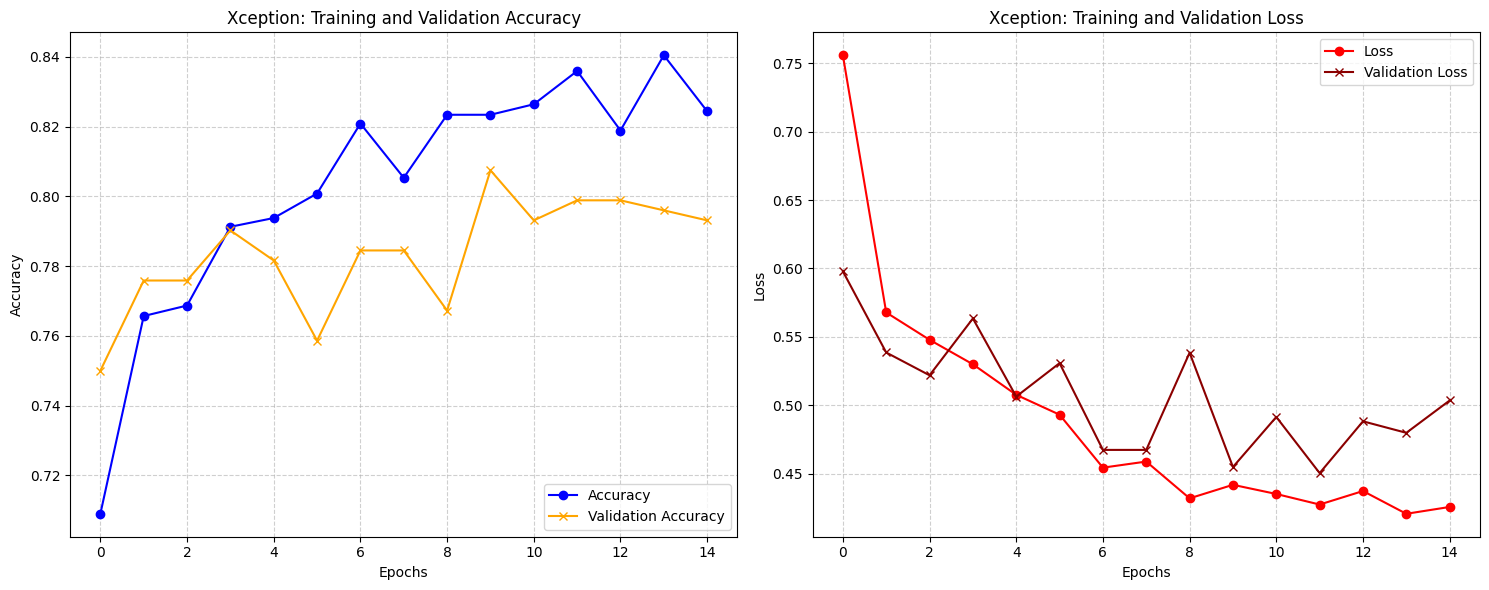

In [46]:
acc = history_fine.history['accuracy']
val_acc = history_fine.history['val_accuracy']
loss = history_fine.history['loss']
val_loss = history_fine.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('Xception: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('Xception: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [28]:
from tensorflow.keras.applications.efficientnet import preprocess_input

eff_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input, # Use the model's native scaler
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    vertical_flip=True,
    fill_mode='nearest',
    validation_split=0.15
)

eff_train_gen = eff_train_datagen.flow_from_directory(
    path_to_train,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

eff_val_gen = eff_train_datagen.flow_from_directory(
    path_to_train,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
from tensorflow.keras.applications import EfficientNetB0
eff_base = EfficientNetB0(weights='imagenet', include_top=False, input_shape=(299,299,3))
eff_base.trainable = False

model_eff = Sequential([
    eff_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model_eff.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

Found 1993 images belonging to 5 classes.
Found 348 images belonging to 5 classes.


In [42]:
history_eff = model_eff.fit(
    eff_train_gen,
    epochs=epochs,
    callbacks=[callback1, callback2],
    validation_data=eff_val_gen,
)

Epoch 1/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 793ms/step - accuracy: 0.8526 - loss: 0.4298 - val_accuracy: 0.8333 - val_loss: 0.4309 - learning_rate: 1.0000e-06
Epoch 2/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 50s 787ms/step - accuracy: 0.8513 - loss: 0.4206 - val_accuracy: 0.8391 - val_loss: 0.4438 - learning_rate: 1.0000e-06
Epoch 3/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 657ms/step - accuracy: 0.8398 - loss: 0.4270
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999974752428e-08.
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 771ms/step - accuracy: 0.8399 - loss: 0.4270 - val_accuracy: 0.8333 - val_loss: 0.4444 - learning_rate: 1.0000e-06
Epoch 4/15
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 770ms/step - accuracy: 0.8558 - loss: 0.3979 - val_accuracy: 0.8276 - val_loss: 0.4843 - learning_rate: 1.0000e-07
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


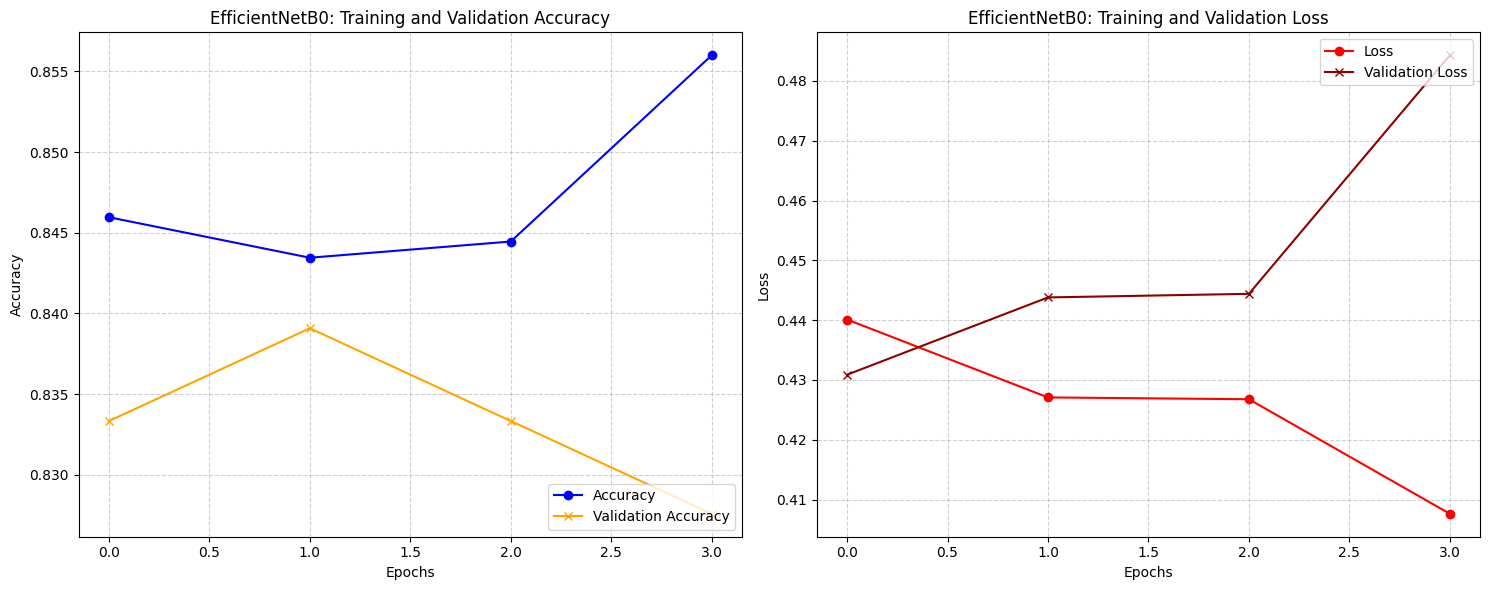

In [45]:
acc = history_eff.history['accuracy']
val_acc = history_eff.history['val_accuracy']
loss = history_eff.history['loss']
val_loss = history_eff.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('EfficientNetB0: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('EfficientNetB0: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [31]:
eff_base.trainable = True

for layer in eff_base.layers[:-20]:
    layer.trainable = False

model_eff.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_eff_fine = model_eff.fit(
    eff_train_gen,
    epochs=10,
    validation_data=eff_val_gen,
    callbacks=[callback1, callback2]
)

Epoch 1/10


2026-03-03 09:09:53.759836: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:09:53.901105: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


47/63 ━━━━━━━━━━━━━━━━━━━━ 10s 640ms/step - accuracy: 0.8377 - loss: 0.4768

2026-03-03 09:10:35.826366: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:10:35.966483: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 94s 1s/step - accuracy: 0.8392 - loss: 0.4687 - val_accuracy: 0.8448 - val_loss: 0.3712 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 747ms/step - accuracy: 0.8506 - loss: 0.4119 - val_accuracy: 0.8132 - val_loss: 0.4547 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 635ms/step - accuracy: 0.8637 - loss: 0.3937
Epoch 3: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 751ms/step - accuracy: 0.8637 - loss: 0.3938 - val_accuracy: 0.8161 - val_loss: 0.4093 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 47s 750ms/step - accuracy: 0.8570 - loss: 0.3850 - val_accuracy: 0.8333 - val_loss: 0.4106 - learning_rate: 1.0000e-06
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.


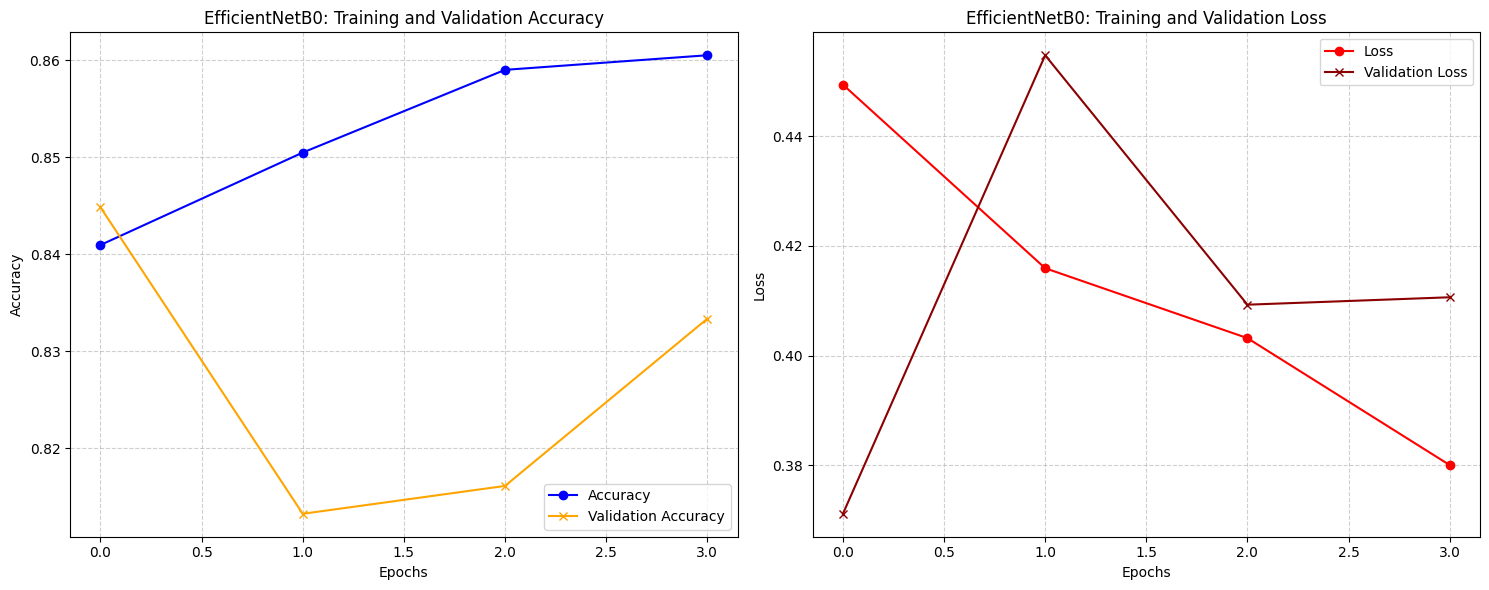

In [44]:
acc = history_eff_fine.history['accuracy']
val_acc = history_eff_fine.history['val_accuracy']
loss = history_eff_fine.history['loss']
val_loss = history_eff_fine.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('EfficientNetB0: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('EfficientNetB0: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [32]:
conv_datagen = ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True,
    validation_split=0.15
)

conv_train_gen = conv_datagen.flow_from_directory(
    path_to_train,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='training'
)

conv_val_gen = conv_datagen.flow_from_directory(
    path_to_train,
    target_size=(299, 299),
    batch_size=32,
    class_mode='categorical',
    subset='validation'
)
from tensorflow.keras.applications import ConvNeXtTiny

conv_base = ConvNeXtTiny(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
conv_base.trainable = False

model_conv = Sequential([
    conv_base,
    layers.GlobalAveragePooling2D(),
    layers.Dense(256, activation='gelu'), # ConvNeXt often uses GELU instead of ReLU
    layers.Dropout(0.3),
    layers.Dense(5, activation='softmax')
])

model_conv.compile(
    optimizer=keras.optimizers.Adam(1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
history_conv = model_conv.fit(
    conv_train_gen,
    epochs=10,
    validation_data=conv_val_gen,
    callbacks=[callback1, callback2]
)

Found 1993 images belonging to 5 classes.
Found 348 images belonging to 5 classes.
111650432/111650432 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Epoch 1/10


2026-03-03 09:31:58.694705: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:31:58.830231: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


24/63 ━━━━━━━━━━━━━━━━━━━━ 25s 662ms/step - accuracy: 0.4524 - loss: 1.3308

2026-03-03 09:32:21.663494: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:32:21.798527: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 740ms/step - accuracy: 0.5563 - loss: 1.0972

2026-03-03 09:33:03.466918: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:33:03.602427: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 81s 1s/step - accuracy: 0.5579 - loss: 1.0934 - val_accuracy: 0.7328 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 777ms/step - accuracy: 0.7461 - loss: 0.5856 - val_accuracy: 0.7960 - val_loss: 0.4812 - learning_rate: 0.0010
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 777ms/step - accuracy: 0.8041 - loss: 0.4627 - val_accuracy: 0.7845 - val_loss: 0.4869 - learning_rate: 0.0010
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 778ms/step - accuracy: 0.8194 - loss: 0.4488 - val_accuracy: 0.8103 - val_loss: 0.4629 - learning_rate: 0.0010
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 775ms/step - accuracy: 0.8248 - loss: 0.4012 - val_accuracy: 0.8161 - val_loss: 0.4231 - learning_rate: 0.0010
Epoch 6/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 784ms/step - accuracy: 0.8711 - loss: 0.3478 - val_accuracy: 0.8046 - val_loss: 0.4327 - learning_rate: 0.0010
Epoch 7/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 49s 773ms/step - accuracy: 0.8499 - loss: 0.3526 - val_acc

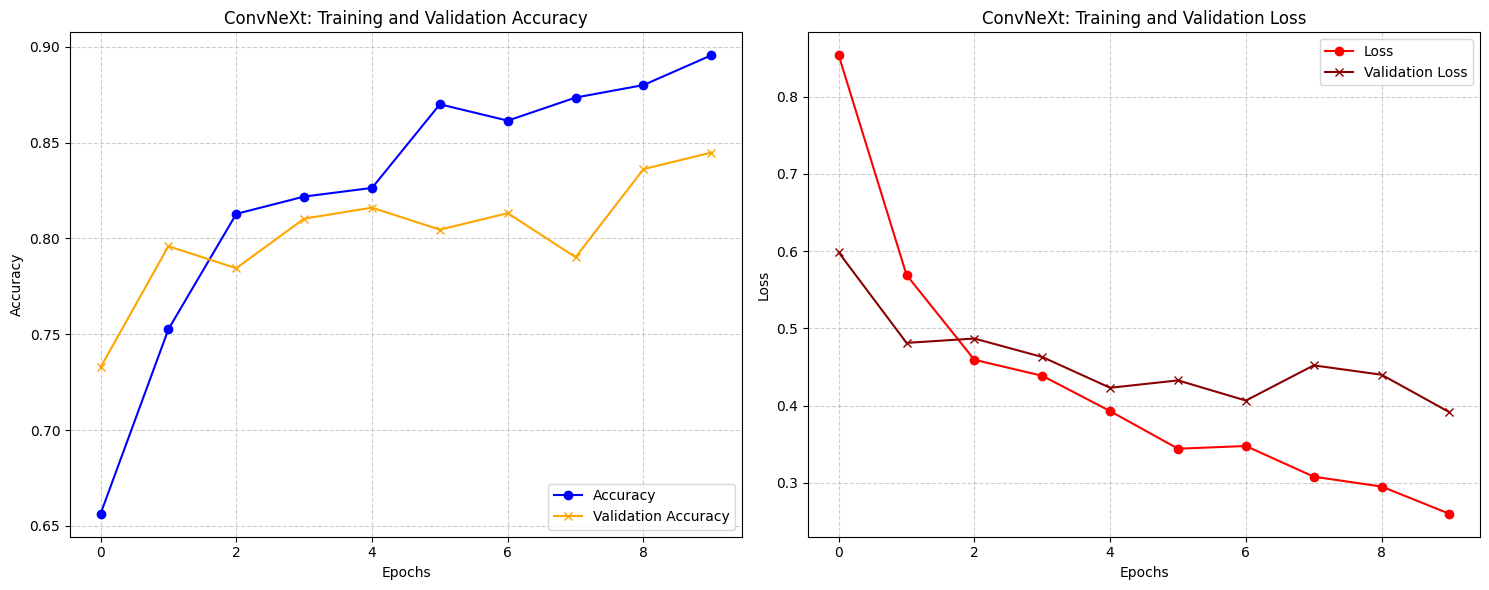

In [36]:
acc = history_conv.history['accuracy']
val_acc = history_conv.history['val_accuracy']
loss = history_conv.history['loss']
val_loss = history_conv.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('ConvNeXt: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('ConvNeXt: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [33]:
conv_base.trainable = True

for layer in conv_base.layers[:-20]:
    layer.trainable = False

model_conv.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_conv_fine = model_conv.fit(
    conv_train_gen,
    epochs=10,
    validation_data=conv_val_gen,
    callbacks=[callback1, callback2]
)

Epoch 1/10


2026-03-03 09:49:04.179044: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:49:04.323461: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:49:04.458840: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


32/63 ━━━━━━━━━━━━━━━━━━━━ 21s 702ms/step - accuracy: 0.8917 - loss: 0.2719

2026-03-03 09:49:36.623439: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
2026-03-03 09:49:36.769033: E external/local_xla/xla/stream_executor/cuda/cuda_timer.cc:86] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


63/63 ━━━━━━━━━━━━━━━━━━━━ 88s 1s/step - accuracy: 0.8986 - loss: 0.2649 - val_accuracy: 0.8420 - val_loss: 0.4153 - learning_rate: 1.0000e-05
Epoch 2/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 802ms/step - accuracy: 0.9168 - loss: 0.2180 - val_accuracy: 0.8621 - val_loss: 0.3692 - learning_rate: 1.0000e-05
Epoch 3/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 812ms/step - accuracy: 0.9263 - loss: 0.2177 - val_accuracy: 0.8391 - val_loss: 0.3746 - learning_rate: 1.0000e-05
Epoch 4/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 704ms/step - accuracy: 0.9291 - loss: 0.2115
Epoch 4: ReduceLROnPlateau reducing learning rate to 9.999999747378752e-07.
63/63 ━━━━━━━━━━━━━━━━━━━━ 52s 824ms/step - accuracy: 0.9291 - loss: 0.2117 - val_accuracy: 0.8477 - val_loss: 0.3771 - learning_rate: 1.0000e-05
Epoch 5/10
63/63 ━━━━━━━━━━━━━━━━━━━━ 51s 805ms/step - accuracy: 0.9275 - loss: 0.2008 - val_accuracy: 0.8448 - val_loss: 0.4199 - learning_rate: 1.0000e-06
Epoch 5: early stopping
Restoring model weights from the end of the best epoch

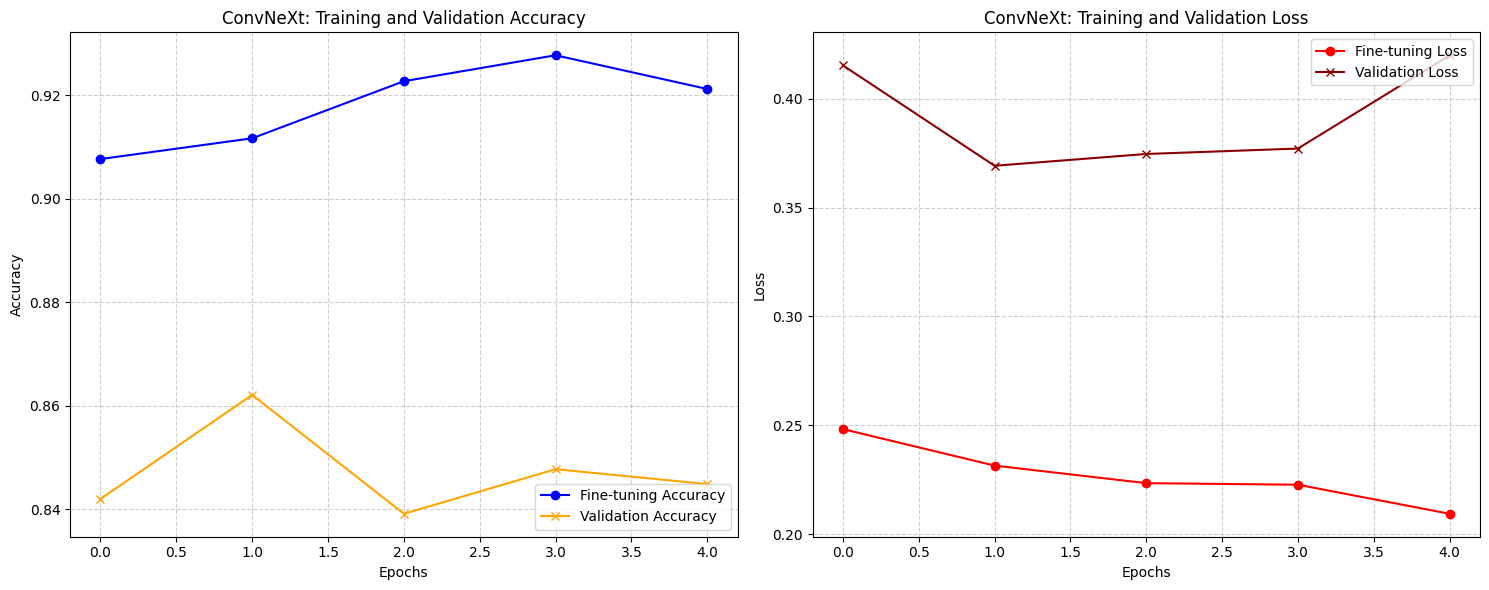

In [34]:
acc = history_conv_fine.history['accuracy']
val_acc = history_conv_fine.history['val_accuracy']
loss = history_conv_fine.history['loss']
val_loss = history_conv_fine.history['val_loss']
epochs_range = range(len(acc))

plt.figure(figsize=(15, 6))

# Plot Accuracy
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Fine-tuning Accuracy', marker='o', color='blue')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='x', color='orange')
plt.title('ConvNeXt: Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True, linestyle='--', alpha=0.6)

# Plot Loss
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Fine-tuning Loss', marker='o', color='red')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='x', color='darkred')
plt.title('ConvNeXt: Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

In [51]:
test_dir = '/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma/test'
test_filenames = os.listdir(test_dir)
test_df = pd.DataFrame({'filename': test_filenames})

print(f"Total test images found: {len(test_df)}")

test_gen_xcp = ImageDataGenerator(rescale=1./255).flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col='filename',
    y_col=None,
    target_size=(299, 299),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

test_gen_eff = ImageDataGenerator(preprocessing_function=eff_preprocess).flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col='filename',
    y_col=None,
    target_size=(299, 299),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

test_gen_conv = ImageDataGenerator().flow_from_dataframe(
    dataframe=test_df,
    directory=test_dir,
    x_col='filename',
    y_col=None,
    target_size=(299, 299),
    batch_size=1,
    class_mode=None,
    shuffle=False
)

Total test images found: 257
Found 257 validated image filenames.
Found 257 validated image filenames.
Found 257 validated image filenames.


In [57]:
model.save('xception_model.keras')
model_eff.save('efficientnet_model.keras')
model_conv.save('convnext_model.keras')

import json
with open('class_indices.json', 'w') as f:
    json.dump(class_indices, f)

print("Models and class indices saved successfully.")

Models and class indices saved successfully.


In [ ]:
p_xcp = model.predict(test_gen_xcp, verbose=1)
p_eff = model_eff.predict(test_gen_eff, verbose=1)
p_conv = model_conv.predict(test_gen_conv, verbose=1)

# Weighted Average Ensemble
final_preds = (0.2 * p_xcp) + (0.4 * p_eff) + (0.4 * p_conv)
final_indices = np.argmax(final_preds, axis=1)

class_indices = train_generator.class_indices
labels_map = {v: k for k, v in class_indices.items()}
final_labels = [labels_map[idx] for idx in final_indices]

submission = pd.DataFrame({
    'image_path': test_df['filename'],
    'Class': final_labels
})

# Save and Check
submission.to_csv('submission.csv', index=False)
print(submission.head())

257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step
257/257 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step
257/257 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step
     image_path       Class
0  image233.jpg      sukhoi
1  image106.jpg  helicopter
2   image27.jpg      mig-29
3  image109.jpg  helicopter
4   image56.jpg      glider


In [56]:
sample_sub = pd.read_csv('/kaggle/input/competitions/anyas-gojo-revival-aerospace-enigma/sample_submission.csv')

preds_dict = dict(zip(submission['image_path'], submission['Class']))

sample_sub['Class'] = sample_sub['image_path'].map(preds_dict)

if sample_sub['Class'].isnull().any():
    print("Warning: Some images in the sample submission were not found in your predictions!")

sample_sub.to_csv('submission.csv', index=False)
print("Formatted submission saved!")
print(sample_sub.head())

🚀 Formatted submission saved!
     image_path       Class
0  image123.jpg  helicopter
1   image53.jpg      glider
2  image228.jpg      sukhoi
3  image225.jpg      sukhoi
4   image82.jpg      glider
